C:\Users\55629\AppData\Local\Temp\ipykernel_6184\2144857980.py:75: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Token.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  vector_max = doc_ref.similarity(doc_q)


,Indice,Texto
0,4,"economia , pois estão no \n setor privado ( po..."
1,34,quem quer que seja sem a \n anuência expressa ...
2,38,da possibilidade de fundar uma EJ \n multidisc...
3,39,a boa e uma das mais eficientes ferramentas de...
4,40,": estrutura , objetivos e processos internos q..."
5,41,já estiver sido “ apadrinhada ” por \n uma EJ ...
6,43,vai \n ser abordado ) . \n Fase 2 : Análise \...
7,45,que \n estes sejam os únicos e os melhores . P...
8,50,pelas disposições legais \n aplicáveis . \n E...
9,53,A aceitação do membro \n geralmente é função d...


,Indice,Texto,N_atenction,Referencia
0,117,"valores serão seguidos , é preciso \n atentar ...",13,qual valor o e lembrar que a se preciso ser se...
1,124,"Aliás , não só entre os membros , também a Ins...",10,qual o e antes que a se ser de ?
2,97,No segundo ponto : produção – deve ser analisa...,9,qual o e que a se ser seguir de
3,104,capital que ela está investindo na EJ renderá ...,9,valor o e que a se ser seguir de
4,87,que responderá e assinará os projetos \n reali...,9,qual o e que a se ser de ?
5,143,"Geralmente , após este primeiro contato não pr...",9,qual o e lembrar que a se ser de
6,94,como clientes e até mesmo \n concorrentes . Po...,8,qual o e que se listar ser de
7,134,", mais uma vez , é necessária a \n ajuda de pr...",8,o e antes que a se ser de
8,90,"pensada , pelo menos se deve citar que \n have...",8,o e antes que se preciso ser de
9,40,": estrutura , objetivos e processos internos q...",8,o e que se ser seguir de ?


,Palavra,Valor
0,EJ,390
1,ser,253
2,Júnior,190
3,Empresa,149
4,membro,139
...,...,...
4236,AL,1
4237,Penedo,1
4238,N,1
4239,S,1


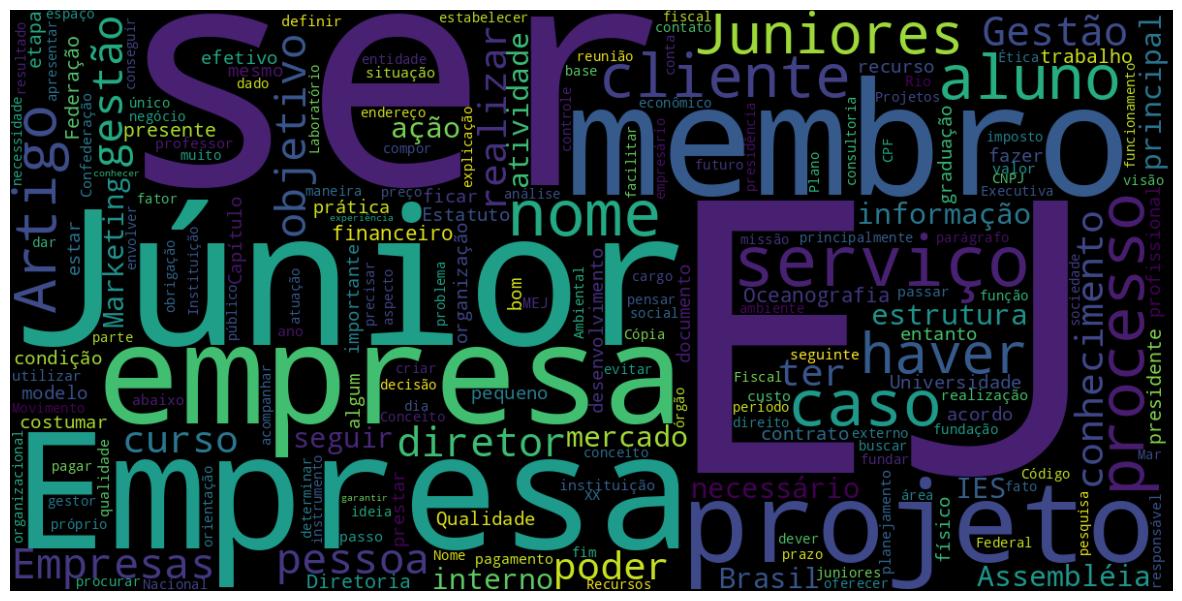

In [ ]:
import pandas as pd 
import pymupdf
from functools import partial
from toolz import compose,compose_left
import spacy
import plotly.express as px 
from wordcloud import WordCloud
from collections import Counter,namedtuple,deque,defaultdict
import pprint
import matplotlib.pyplot as plt


class Classe_modelo_01() :
    def __init__(self,query):
        self.query = query
        self.desencadear()
    

    def desencadear(self) :
        # self.criar_texto_bruto()
        self.criar_parametros()
        # self.criar_chunks()
        self.pesquisar_semantica()
        self.pesquisa_sintatica()
        self.geracao_graficos()

        
    def criar_parametros(self) :
        self.nlp = spacy.load("pt_core_news_sm")


    def criar_texto_bruto(self) :
        caminho_0 = r".\pdfs\Guia de empresas juniores.pdf"
        caminho_1 = r".\arquivos_contexto\Base_bruta.txt"
        doc = pymupdf.open(caminho_0)
        with open(caminho_1,"w",encoding="utf-8") as arquivo_tt :
            for page in doc :
                texto = page.get_text()
                arquivo_tt.write(texto)


    def criar_chunks(self) :
        caminho_1 = r".\arquivos_contexto\Base_bruta.txt"
        with open(caminho_1,"r",encoding="utf-8") as arquivo_tt :
            conteudo = arquivo_tt.read().strip()
        lista_frame = []
        lista_vazia = []
        n_chunks = 258
        doc = self.nlp(conteudo)
        val_conte = ""
        x = 1
        for docs in doc :
            val_conte = f"{val_conte} {docs}"
            lista_vazia.append(docs)
            if len(lista_vazia) >= n_chunks :
                lista_frame.append({"Indice":x,"Texto":val_conte.strip()})
                val_conte = ""
                lista_vazia = []
                x += 1
        frame_f = pd.DataFrame(lista_frame)
        frame_f.to_json(r".\frames\chunks.json",orient="records",force_ascii=False,indent=4)
        display(frame_f)



    def pesquisar_semantica(self) :
        caminho = r".\frames\chunks.json"
        frame_ref = pd.DataFrame(pd.read_json(caminho))
        doc_q = self.nlp(self.query)
        scores_ref = []
        for i , msg_ref in enumerate(frame_ref["Texto"]) :
            doc_nl = self.nlp(msg_ref)
            sm = []
            for doc_ref in doc_nl :
                vector_max = doc_ref.similarity(doc_q)
                sm.append(vector_max)
            val_max = max(sm)
            scores_ref.append({"Indice":frame_ref.loc[i,"Indice"],"Valor":val_max})
        frame_fim = pd.DataFrame(scores_ref)
        frame_fim = frame_fim.sort_values(by="Valor",ascending=False).reset_index(drop=True)
        filtro = frame_ref[frame_ref["Indice"].isin(frame_fim["Indice"].head(30).unique())].reset_index(drop=True)
        filtro = filtro.sort_values(by="Indice").reset_index(drop=True)
        self.frame_c01 = filtro.copy()
        display(filtro)


    def pesquisa_sintatica(self) :
        lemma_q = {x.lemma_ for x in self.nlp(self.query)}
        lista_frame = []
        for i , msg_ref in enumerate(self.frame_c01["Texto"]) :
            lemma_doc = {x.lemma_ for x in self.nlp(msg_ref)}
            if lemma_q.intersection(lemma_doc) :
                pal_ref0 = ""
                for g in lemma_q.intersection(lemma_doc) :
                    pal_ref0 = f"{pal_ref0} {g}".strip()
                lista_frame.append({"Indice":self.frame_c01.loc[i,"Indice"],"Texto":msg_ref,"N_atenction":len(lemma_q.intersection(lemma_doc)),"Referencia" :pal_ref0})
        frame_final = pd.DataFrame(lista_frame)
        frame_final = frame_final.drop_duplicates(subset="Indice").reset_index(drop=True)
        frame_final = frame_final.sort_values(by="N_atenction",ascending=False).reset_index(drop=True)
        display(frame_final)


    def geracao_graficos(self) :
        caminho_1 = r".\arquivos_contexto\Base_bruta.txt"
        with open(caminho_1,"r",encoding="utf-8") as arquivo_tt :
            conteudo = arquivo_tt.read().strip()
        doc = self.nlp(conteudo.strip())
        dict_cont = Counter([x.lemma_ for x in doc if x.is_alpha and not x.is_stop])
        lista_frame = []
        for chave , valor in dict_cont.items() :
            lista_frame.append({"Palavra":chave,"Valor":valor})
        frame_fim = pd.DataFrame(lista_frame)
        frame_fim = frame_fim.sort_values(by="Valor",ascending=False).reset_index(drop=True)
        display(frame_fim)
        wc = WordCloud(
            width=1200,
            height=600,
            background_color="black",
            colormap="viridis",
            max_words=200,
            random_state=42
        )
        wc.generate_from_frequencies(dict_cont)
        plt.figure(figsize=(15, 8))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.show()


Classe_modelo_01("qual o detalhe que e preciso se lembrar antes de listar os valores a serem seguidos ?")


In [ ]:
import pandas as pd 
import numpy as np 
import random as rd 
import pymupdf
import spacy
import os 
import re 
import shutil
from functools import partial
from toolz import compose,compose_left
import unicodedata




class Classe_criador_chunks() :
    def __init__(self,query) :
        self.query = query
        self.desencadear()


    def desencadear(self) :
        self.criar_parametros()
        self.extracao_pdf()
        self.criacao_chunks()
        self.busca_semantica()
        self.busca_lexica()


    def normalizar_texto(self,texto=None):
        # 1. Minúsculas
        texto = texto.lower()

        # 2. Remove URLs
        texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)

        # 3. Remove e-mails
        texto = re.sub(r'\S+@\S+', ' ', texto)

        # 4. Remove acentos
        texto = unicodedata.normalize("NFD", texto)
        texto = "".join(
            caractere
            for caractere in texto
            if unicodedata.category(caractere) != "Mn"
        )

        # 5. Remove caracteres especiais
        # Mantém letras, números e espaços
        texto = re.sub(r'[^a-z0-9\s]', ' ', texto)

        # 6. Remove espaços duplicados
        texto = re.sub(r'\s+', ' ', texto).strip()

        return texto


    def criar_parametros(self) :
        self.nlp = spacy.load("pt_core_news_sm")


    def extracao_pdf(self) :
        caminho_pdf = r".\pdfs\Guia de empresas juniores.pdf"
        caminho_txt = r".\arquivos_contexto\base_bruta_texto.txt"
        arquivo_pdf = pymupdf.open(caminho_pdf)
        with open(caminho_txt,"w",encoding="utf-8") as arquivo_tt :
            for page in arquivo_pdf :
                text_ref = page.get_text()
                arquivo_tt.write(text_ref)


    def criacao_chunks(self) :
        caminho_txt = r".\arquivos_contexto\base_bruta_texto.txt"
        with open(caminho_txt,"r",encoding="utf-8") as arquivo_tt :
            conteudo = arquivo_tt.read()
        ajustar_texto = partial(self.normalizar_texto,texto=conteudo)
        conteudo_01 = ajustar_texto()
        doc = self.nlp(conteudo_01)
        lista_chunks = []
        lista_frame = []
        x = 1
        for docs in doc :
            lista_chunks.append(docs)
            if len(lista_chunks) >= 258 :
                var_contex = f""""""
                for a in lista_chunks :
                    var_contex = f"""{var_contex} {a}"""
                lista_frame.append({"Chunk":x,"Conteudo":var_contex})
                lista_chunks = []
                x += 1
        frame_final = pd.DataFrame(lista_frame)
        self.frame_chunks = frame_final.copy()
        display(frame_final)


    def busca_semantica(self) :
        normalizar_q = partial(self.normalizar_texto,texto=self.query)
        doc = self.nlp(normalizar_q())
        scores = []
        for i , text_ref in enumerate(self.frame_chunks["Conteudo"]) :
            sm = []
            doc_ref = self.nlp(text_ref)
            for o in doc_ref :
                vetor_ref = doc.similarity(o)
                sm.append(vetor_ref)
            val_max = max(sm)
            scores.append({"Chunk":self.frame_chunks.loc[i,"Chunk"],"Valor":val_max})
        frame_scores = pd.DataFrame(scores)
        frame_rela01 = pd.merge(self.frame_chunks,frame_scores,left_on="Chunk",right_on="Chunk",suffixes=("_x","_y"),how="left")
        frame_rela01 = frame_rela01.sort_values(by="Valor",ascending=False).reset_index(drop=True).head(20)
        self.frame_rela02 = frame_rela01.copy()
        display(frame_rela01)


    def busca_lexica(self) :
        normalizar_q = partial(self.normalizar_texto,texto=self.query)
        lemma_q = {x.lemma_ for x in self.nlp(normalizar_q())}
        lista_final = []
        for i , chunk_ref in enumerate(self.frame_rela02["Conteudo"]) :
            lemma_chun = {x.lemma_ for x in self.nlp(chunk_ref)}
            if lemma_q.intersection(lemma_chun) :
                lista_final.append({"Chunk":self.frame_rela02.loc[i,"Chunk"],"Intencidade":len(lemma_q.intersection(lemma_chun)),"Similaridade":lemma_q.intersection(lemma_chun),"Menssagem":chunk_ref,"Referencia_Vetorial":self.frame_rela02.loc[i,"Valor"]})
        frame_final_cor = pd.DataFrame(lista_final)
        frame_final_cor = frame_final_cor.sort_values(by="Intencidade",ascending=False).reset_index(drop=True)
        display(frame_final_cor)

            

        

Classe_criador_chunks("Por esse objetivo entende-se fomentar o crescimento pessoal e profissional do aluno membro, por meio do oferecimento de serviços de qualidade e a um baixo custo ao mercado")

,Chunk,Conteudo
0,1,1 guia de empresas juniores filippe apolo gom...
1,2,da brasil junior 17 capitulo 4 pensar a empre...
2,3,esse objetivo entende se fomentar o crescimen...
3,4,a junior entreprise uma associacao que propor...
4,5,para a identificacao dos cursos de graduacao ...
...,...,...
133,134,mais diversas areas garantindo confiabilidade...
134,135,o giovannetti rafael dos santos vilalva desde...
135,136,turistica e agro negocio tendo sempre em ment...
136,137,flavia previero nogueira diretora de marketin...


C:\Users\55629\AppData\Local\Temp\ipykernel_3612\3176005103.py:104: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  vetor_ref = doc.similarity(o)


,Chunk,Conteudo,Valor
0,122,tudo que foi planejado seja cumprido ja nos a...,0.690035
1,50,abaixo 1 consulta previa do local antes de se...,0.688736
2,62,porque ela pode ser utilizada em diversas sit...,0.682476
3,26,comodato 3 o prazo do contrato de comodato e ...,0.676908
4,2,da brasil junior 17 capitulo 4 pensar a empre...,0.673765
5,79,outra hipotese que nao deve ser descartada e ...,0.669584
6,59,firmados no estatuto ou deixe de registrar to...,0.669333
7,19,por esses empecilhos o movimento empresa juni...,0.668403
8,102,pode limitar a perspectiva de captacao de rec...,0.667666
9,106,da desmotivacao causada pela brusca ruptura d...,0.665664


,Chunk,Intencidade,Similaridade,Menssagem,Referencia_Vetorial
0,40,15,"{servico, e, qualidade, a o, se, a, mercado, p...",no mercado de trabalho e no ambito academico ...,0.655971
1,62,14,"{servico, e, de o, a o, se, a, mercado, por, m...",porque ela pode ser utilizada em diversas sit...,0.682476
2,2,14,"{servico, e, qualidade, a o, se, a, mercado, p...",da brasil junior 17 capitulo 4 pensar a empre...,0.673765
3,59,12,"{servico, e, a o, se, a, por, aluno, o, um, de...",firmados no estatuto ou deixe de registrar to...,0.669333
4,136,12,"{servico, e, qualidade, a o, a, meio, por, alu...",turistica e agro negocio tendo sempre em ment...,0.660078
5,104,12,"{e, de o, a o, se, a, por, membro, um, o, obje...",otimizem o potencial dos membros da ej ademai...,0.663562
6,63,12,"{servico, e, a o, se, a, mercado, por, o, um, ...",primeira impressao e a que fica inclusive no ...,0.662174
7,79,12,"{e, se, a, custo, mercado, por, membro, um, o,...",outra hipotese que nao deve ser descartada e ...,0.669584
8,106,12,"{e, a o, se, a, por, membro, um, o, objetivo, ...",da desmotivacao causada pela brusca ruptura d...,0.665664
9,19,12,"{e, a o, se, a, custo, mercado, por, o, um, de...",por esses empecilhos o movimento empresa juni...,0.668403
